In [1]:
                                                            #.1-Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing
from sklearn import metrics
import warnings
warnings.simplefilter(action="ignore")

In [3]:
                                                           # 2.Importing the DataSet

In [4]:
data = pd.read_csv('cardata.csv')
data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
df = pd.DataFrame(data)
df        

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [6]:
df2 = df.drop(columns="Car_Name")
df2

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [7]:
df2["Age"] = 2019-df2["Year"]
df2.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5


In [8]:
                                                     #-missing value check  # no missing value found

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    object 
 5   Seller_Type    301 non-null    object 
 6   Transmission   301 non-null    object 
 7   Owner          301 non-null    int64  
 8   Age            301 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 21.3+ KB


In [10]:
df2.shape

(301, 9)

In [11]:
df2.describe(include = 'all')

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
count,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000,301.000000
unique,NaN,NaN,NaN,NaN,3,2,2,NaN,NaN
top,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN,NaN
freq,NaN,NaN,NaN,NaN,239,195,261,NaN,NaN
mean,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189,5.372093
std,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915,2.891554
min,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000,1.000000
25%,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000,3.000000
50%,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000,5.000000
75%,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000,7.000000


In [12]:
df2.isna().sum()

Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Age              0
dtype: int64

In [13]:
for column in df2.columns:
    print(f"unique values in '{column}':")
    print(df2[column].unique())
    print("_" * 50)

unique values in 'Year':
[2014 2013 2017 2011 2018 2015 2016 2009 2010 2012 2003 2008 2006 2005
 2004 2007]
__________________________________________________
unique values in 'Selling_Price':
[ 3.35  4.75  7.25  2.85  4.6   9.25  6.75  6.5   8.75  7.45  6.85  7.5
  6.1   2.25  7.75  3.25  2.65  4.9   4.4   2.5   2.9   3.    4.15  6.
  1.95  3.1   2.35  4.95  5.5   2.95  4.65  0.35  5.85  2.55  1.25  1.05
  5.8  14.9  23.   18.   16.    2.75  3.6   4.5   4.1  19.99  6.95 18.75
 23.5  33.   19.75  4.35 14.25  3.95  1.5   5.25 14.5  14.73 12.5   3.49
 35.    5.9   3.45  3.8  11.25  3.51  4.   20.75 17.    7.05  9.65  1.75
  1.7   1.65  1.45  1.35  1.2   1.15  1.11  1.1   1.    0.95  0.9   0.75
  0.8   0.78  0.72  0.65  0.6   0.55  0.52  0.51  0.5   0.48  0.45  0.42
  0.4   0.38  0.31  0.3   0.27  0.25  0.2   0.18  0.17  0.16  0.15  0.12
  0.1   5.75  5.15  7.9   4.85 11.75  3.15  6.45  3.5   8.25  5.11  2.7
  6.15 11.45  3.9   9.1   4.8   2.    5.35  6.25  5.95  5.2   3.75 12.9
  5.    5

In [14]:
df2.describe(include='object').loc[['count', 'unique']].T

,count,unique
Fuel_Type,301,3
Seller_Type,301,2
Transmission,301,2


In [15]:
df2.Seller_Type.value_counts()

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

In [16]:
df2.Transmission.value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

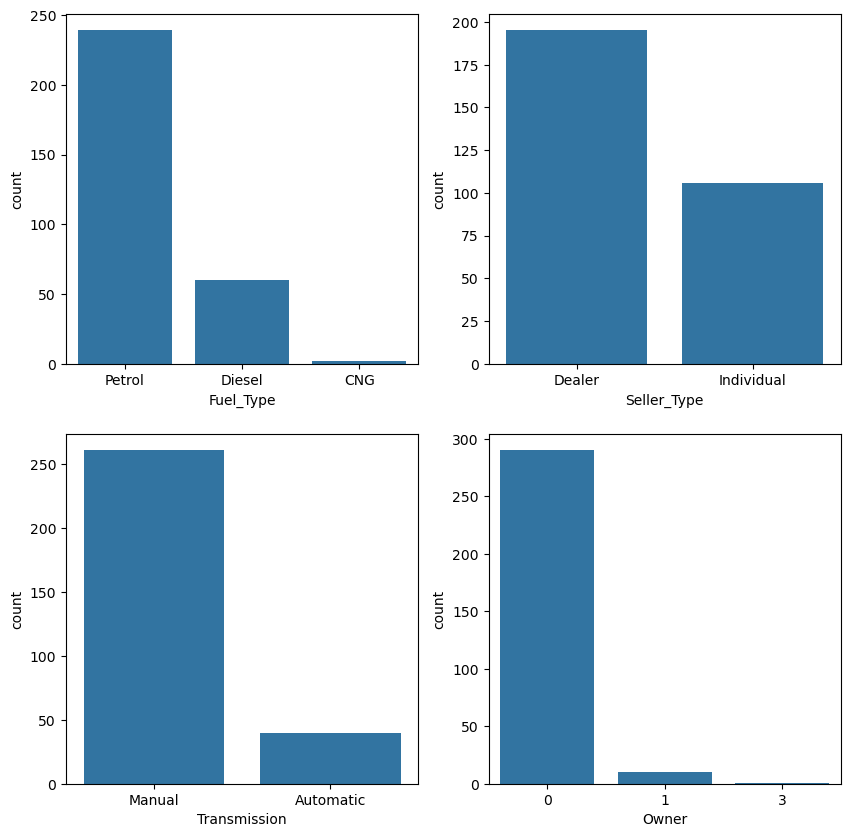

In [17]:
categorical = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
i=0
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for row in range(2) :
    for col in range(2) :
        sns.countplot(x=categorical[i], data = df2, ax=ax[row, col])
        i+=1
plt.show()

In [18]:
df2['Fuel_Type'] = df2['Fuel_Type'].replace({'Petrol': '2', 'Diesel': '3', 'CNG': '4'})
df2['Seller_Type'] = df2['Seller_Type'].replace({'Dealer': '2', 'Individual': '3'})
df2['Transmission'] = df2['Transmission'].replace({'Manual': '2', 'Automatic': '3'})
df2

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,2,2,2,0,5
1,2013,4.75,9.54,43000,3,2,2,0,6
2,2017,7.25,9.85,6900,2,2,2,0,2
3,2011,2.85,4.15,5200,2,2,2,0,8
4,2014,4.60,6.87,42450,3,2,2,0,5
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,3,2,2,0,3
297,2015,4.00,5.90,60000,2,2,2,0,4
298,2009,3.35,11.00,87934,2,2,2,0,10
299,2017,11.50,12.50,9000,3,2,2,0,2


In [19]:
                                                          #3.PreProcessing

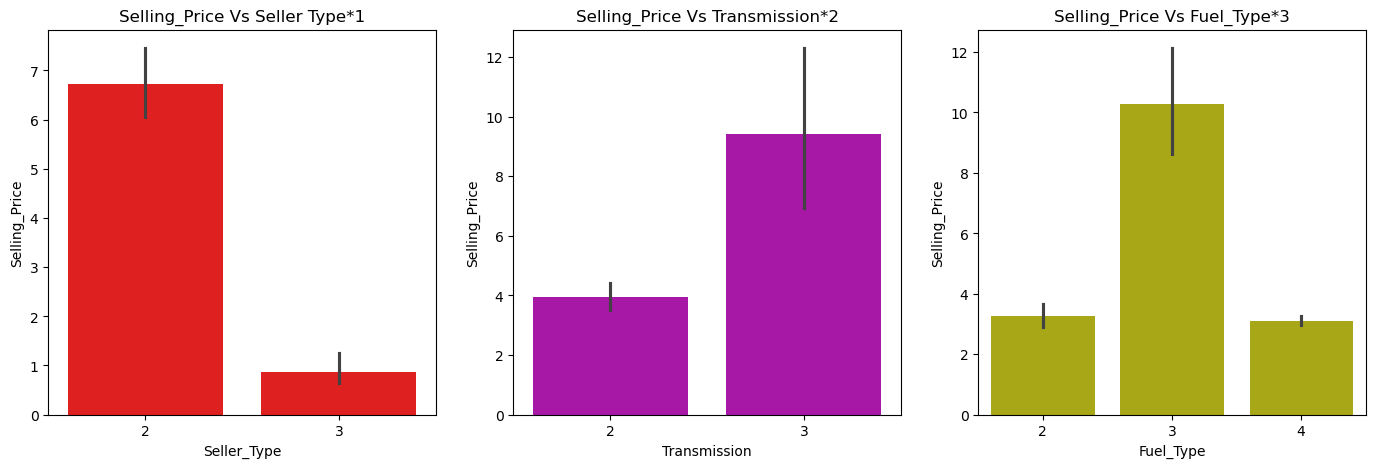

In [20]:
plt.figure(figsize=[17,5],dpi=100)
plt.subplot(1,3,1)
sns.barplot(x = df2['Seller_Type'],y= df2['Selling_Price'],data = df2,color='r')
plt.title('Selling_Price Vs Seller Type*1')

plt.subplot(1,3,2)
sns.barplot(x = df2['Transmission'],y = df2['Selling_Price'],data=df2 , color='m')
plt.title('Selling_Price Vs Transmission*2')

plt.subplot(1,3,3)
sns.barplot(x = df2['Fuel_Type'],y = df2['Selling_Price'],data=df2 ,color='y')
plt.title('Selling_Price Vs Fuel_Type*3')

plt.show()

In [21]:
# 1.Selling Price of cars seems to have higher prices when sold by Dealers when compared to Individuals
# 2.It can be observed that Selling Price would be higher for cars that are Automatic.
# 3.Selling Price of cars with Fuel Type of Diesel is higher than Petrol and CNG


In [22]:
#                                     Replace unique values with integer values usin LabelEncoder()

In [23]:
# Fuel_Type
temp_fuel = LabelEncoder()
df2['Fuel_Type'] = temp_fuel.fit_transform(df2['Fuel_Type'])
df2['Fuel_Type'] = df2['Fuel_Type'] + 2
#####################################################
# Seller_Type
temp_seller = LabelEncoder()
df2['Seller_Type'] = temp_seller.fit_transform(df2['Seller_Type'])
df2['Seller_Type'] = df2['Seller_Type'] + 2
#####################################################
# Transmission
temp_transmition = LabelEncoder()
df2['Transmission'] = temp_transmition.fit_transform(df2['Transmission'])
df2['Transmission'] = df2['Transmission'] + 2
#####################################################
# Owner
temp_owner = LabelEncoder()
df2['Owner'] = temp_owner.fit_transform(df2['Owner'])
df2['Owner'] = df2['Owner'] + 2
#print(colored('Unique Values After exchange', 'blue'))
print('*'*40)
for cat_col in categorical :
   print(cat_col, ' : ', pd.unique(df2[cat_col]))
        # print('_'*40)

****************************************
Fuel_Type  :  [2 3 4]
Seller_Type  :  [2 3]
Transmission  :  [2 3]
Owner  :  [2 3 4]


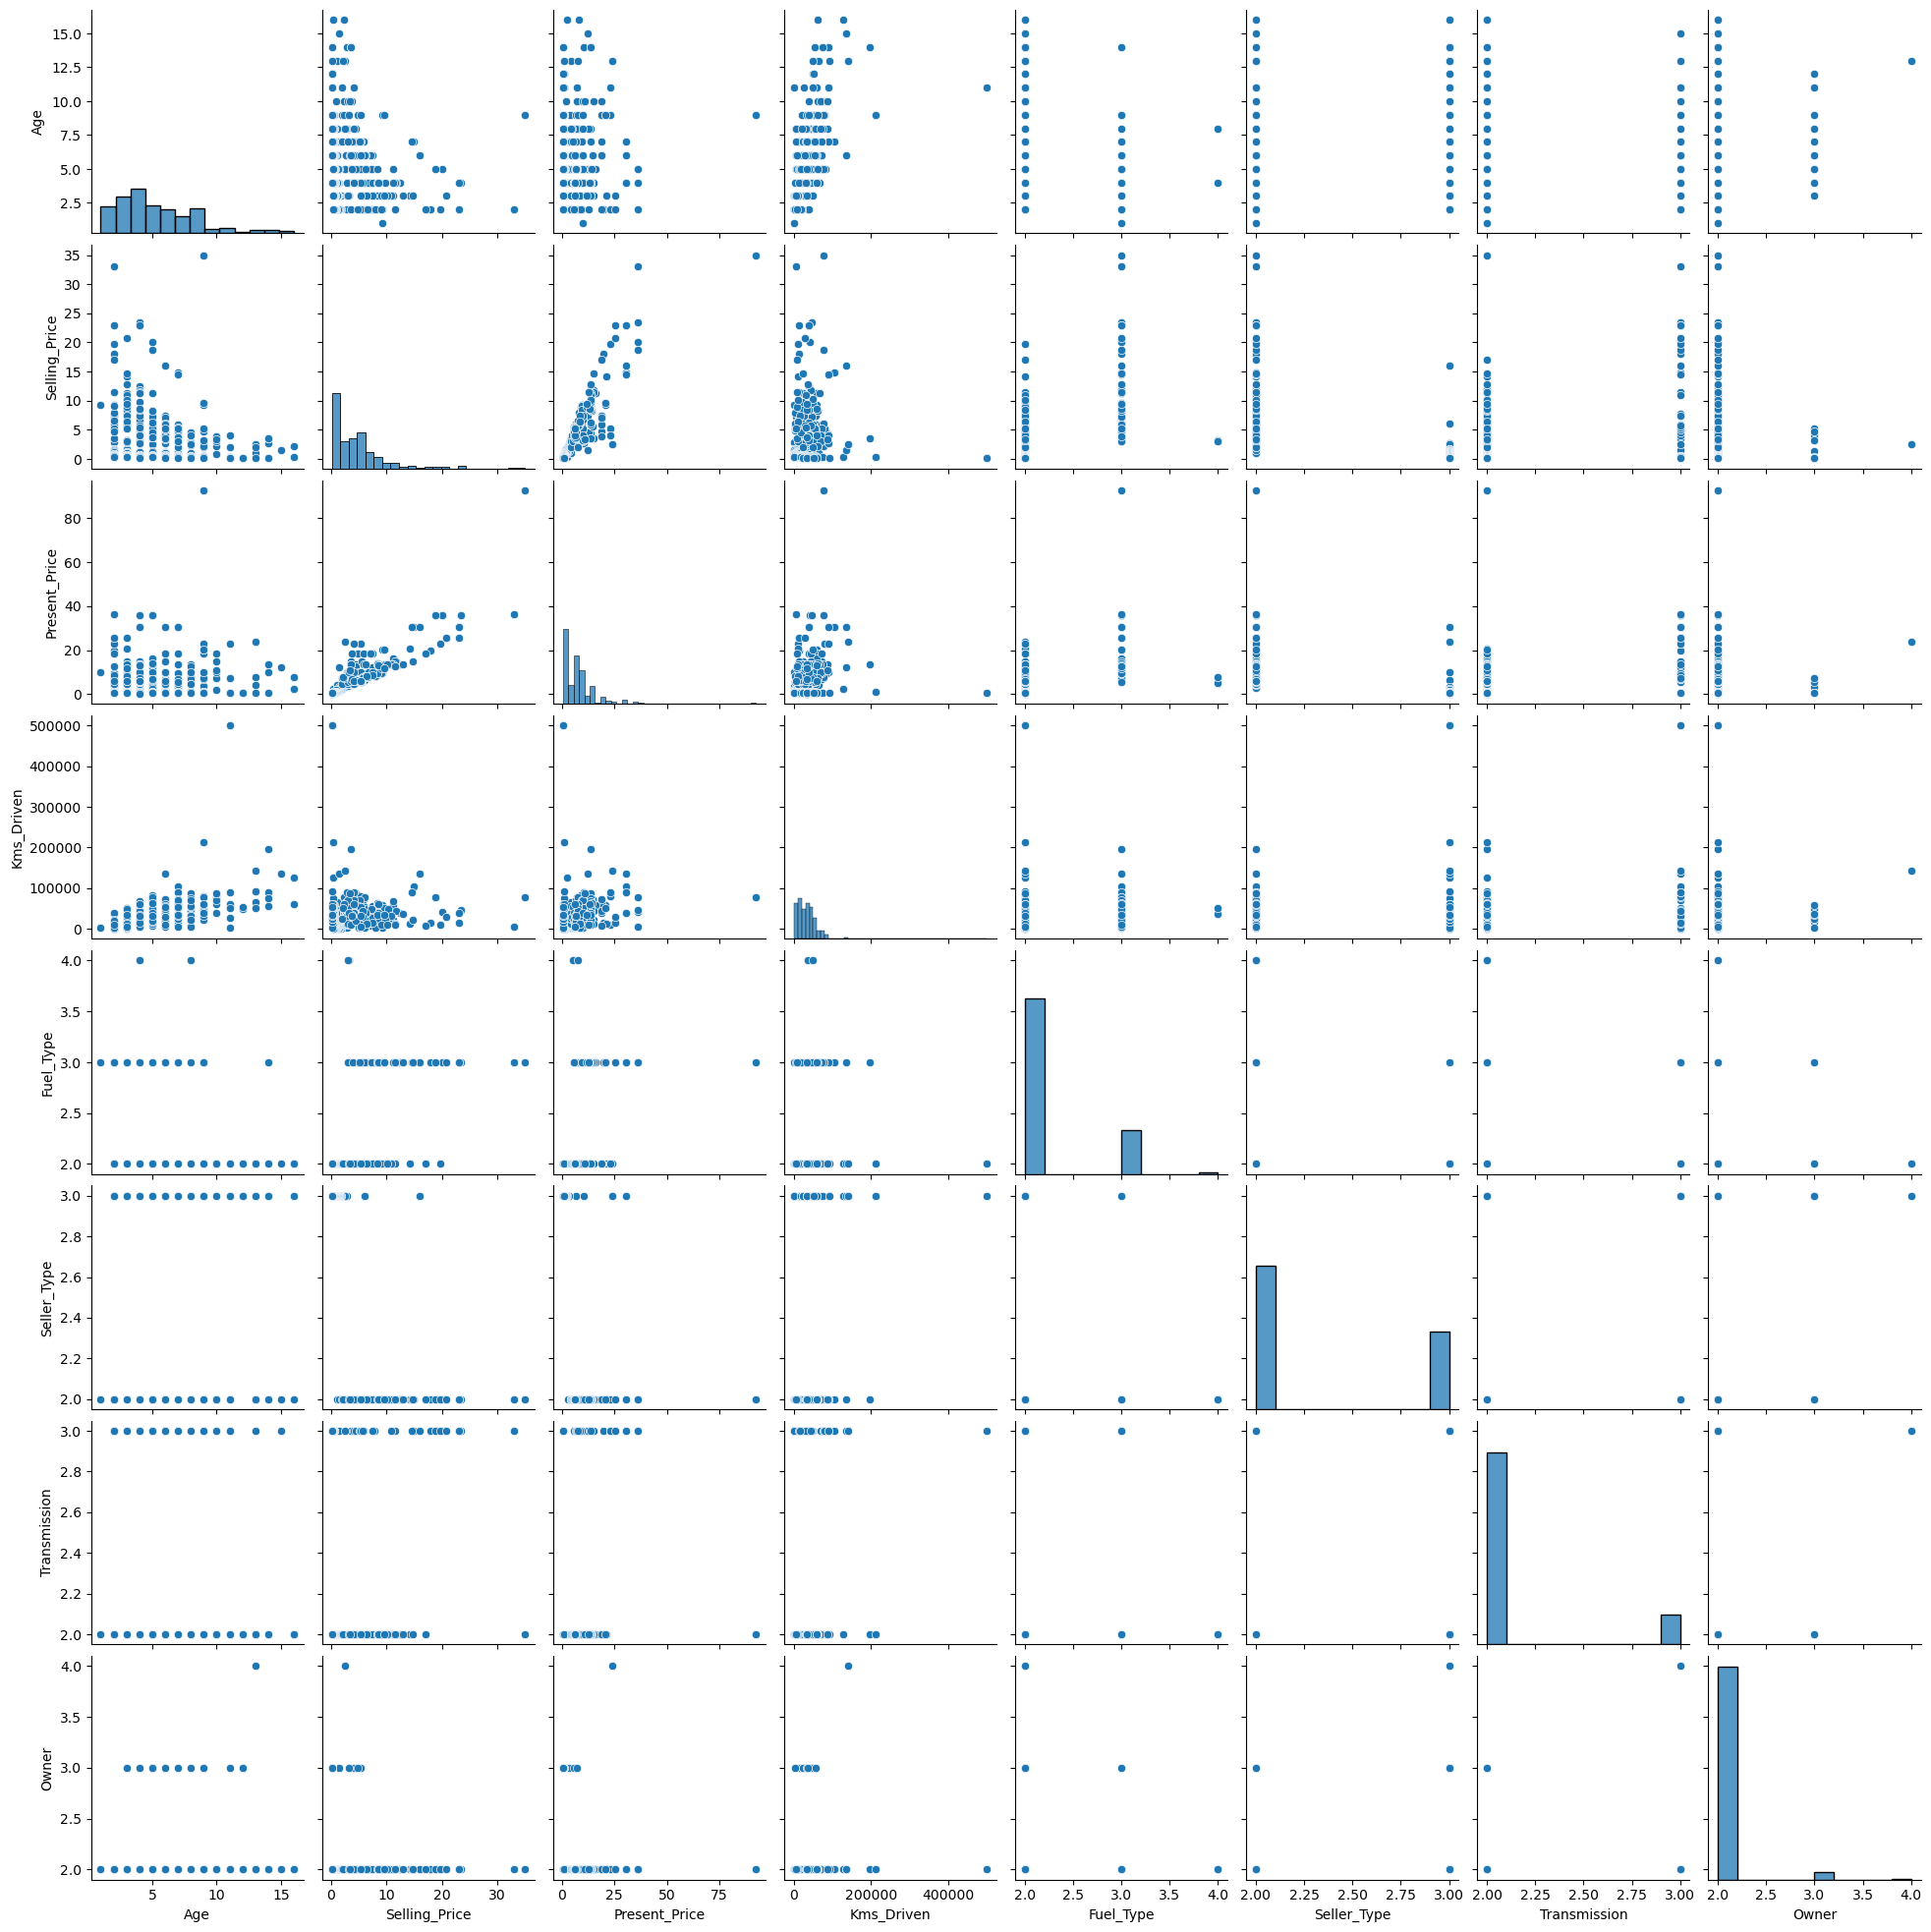

In [24]:
sns.pairplot(df2[['Age', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner']])
plt.show()

In [25]:
                                                           #noise checking 

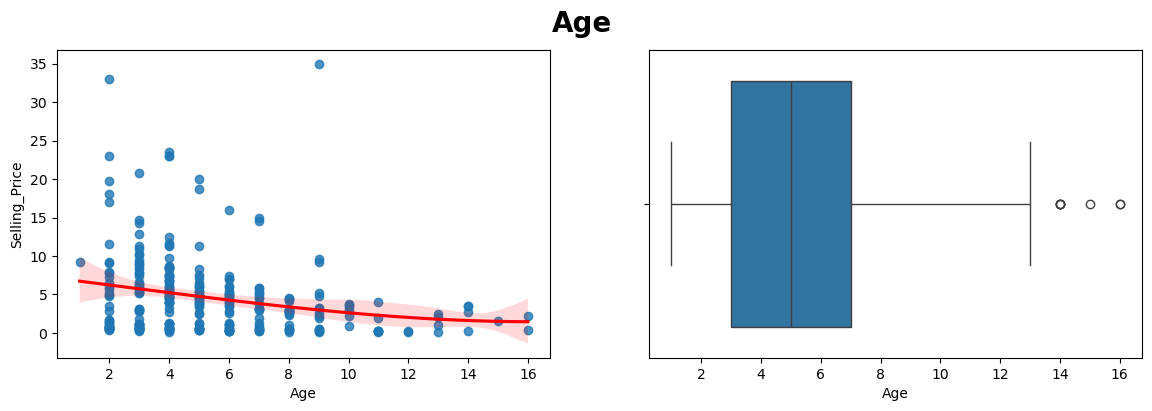

In [26]:
# Age
x = 'Age'

fig = plt.figure(figsize=(14, 4))
plt.suptitle(x, size=20, weight='bold')
# First plot
plt.subplot(1, 2, 1)
sns.regplot(x=x, y=df2.Selling_Price, data=df2, order=3, line_kws=dict(color="red"))

# Second plot
plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df2)

plt.show()

In [27]:
#There is no noises here.
# A non-linear regression is visible.

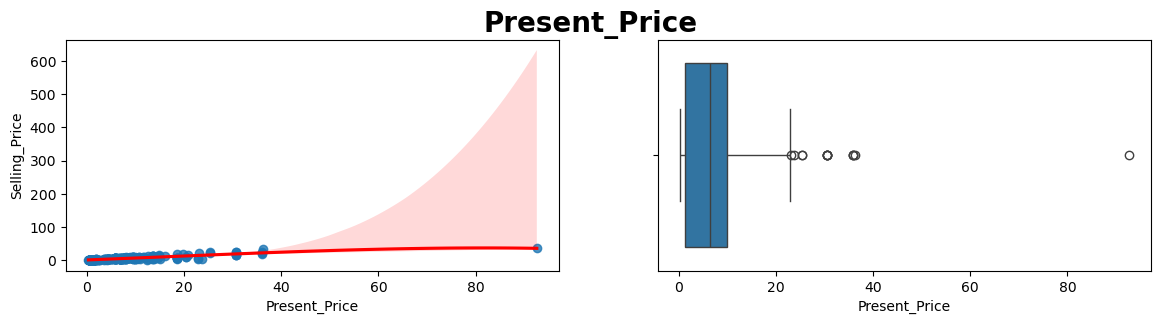

In [28]:
# Present_Price
x = 'Present_Price'

fig = plt.figure(figsize=(14, 3))
plt.suptitle(x, size=20, weight='bold')
# First plot
plt.subplot(1, 2, 1)
sns.regplot(x=x, y=df2.Selling_Price, data=df2, order=3,line_kws=dict(color="red"))

# Second plot
plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df2)

plt.show()

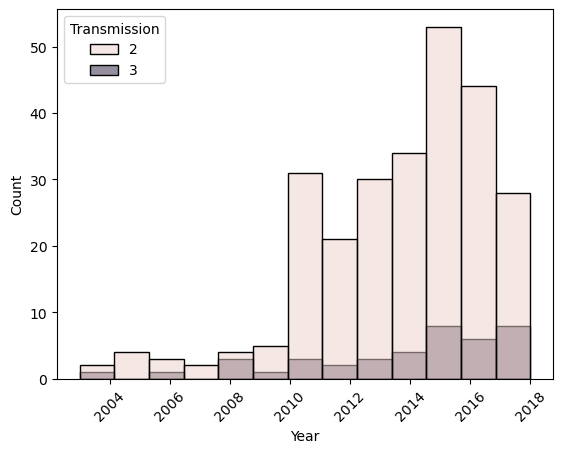

In [29]:
sns.histplot(data=df2, x="Year", hue="Transmission")
plt.xticks(rotation=45)
plt.show()

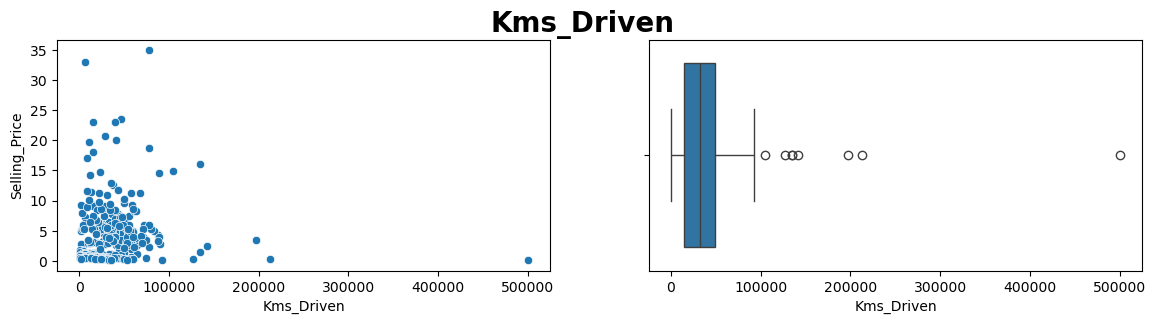

In [30]:
# Kms_Driven
x = 'Kms_Driven'

fig = plt.figure(figsize=(14, 3))
plt.suptitle(x, size=20, weight='bold')
# First plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y=data.Selling_Price, data=data)
# Second plot
plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=data)

plt.show()

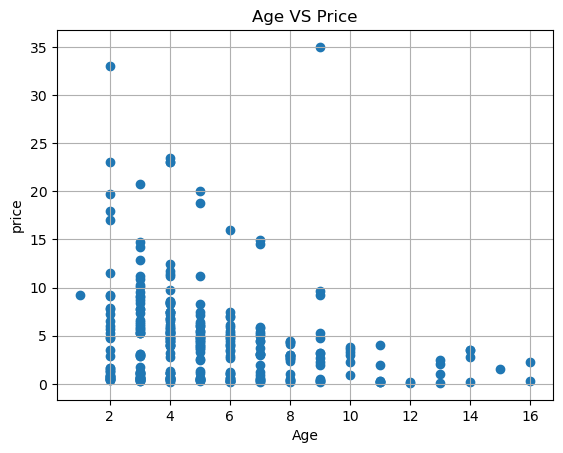

In [31]:
plt.scatter(df2["Age"], df2["Selling_Price"])        # Age VS Price¶

plt.title("Age VS Price")
plt.xlabel("Age")
plt.ylabel("price")
plt.grid()


In [32]:
                                                        #Present_Price VS Price

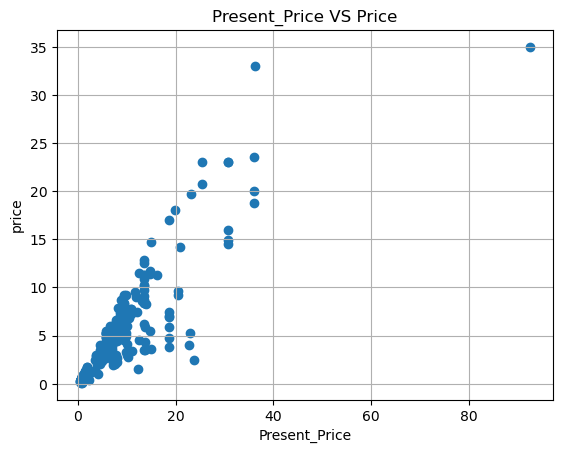

In [33]:
plt.scatter(df2["Present_Price"], df2["Selling_Price"])
plt.title("Present_Price VS Price")
plt.xlabel("Present_Price")
plt.ylabel("price")
plt.grid()

In [34]:
                                                                 #Kms_Driven VS Price

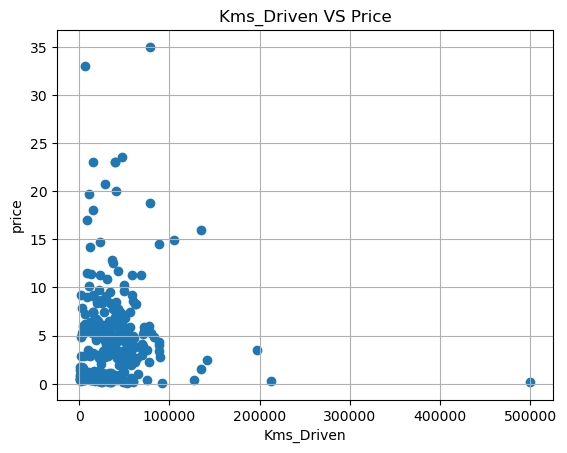

In [35]:
plt.scatter(df2["Kms_Driven"], df2["Selling_Price"])
plt.title("Kms_Driven VS Price")
plt.xlabel("Kms_Driven")
plt.ylabel("price")
plt.grid()

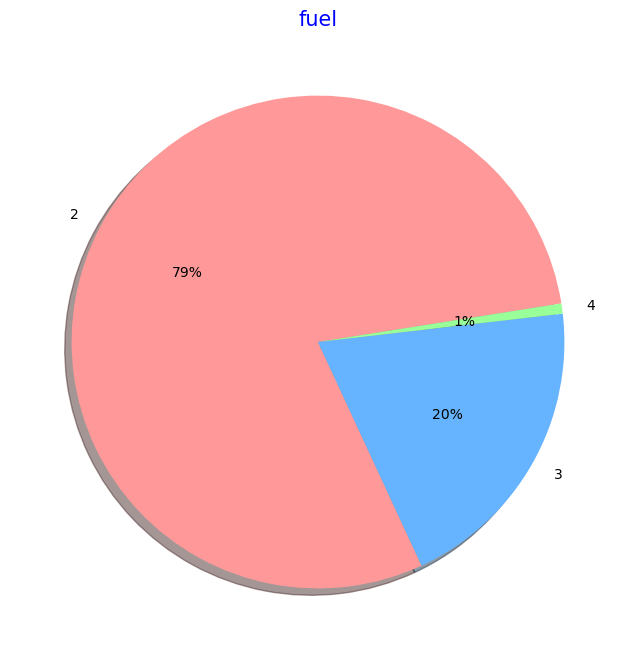

In [36]:
labels = df2["Fuel_Type"].value_counts().index
sizes = df2["Fuel_Type"].value_counts()
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"pink","yellow"]
plt.figure(figsize = (8,8))
plt.pie(sizes, labels=labels, rotatelabels=False, autopct='%1.f%%',colors=colors,shadow=True, startangle=9)
plt.title('fuel',color = 'blue',fontsize = 15)
plt.show()

In [37]:
                                                         #Fuel_Type VS Price

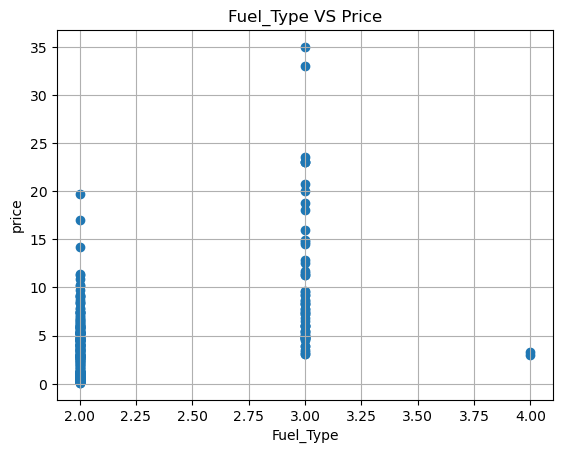

In [38]:
plt.scatter(df2["Fuel_Type"], df2["Selling_Price"])
plt.title("Fuel_Type VS Price")
plt.xlabel("Fuel_Type")
plt.ylabel("price")
plt.grid()

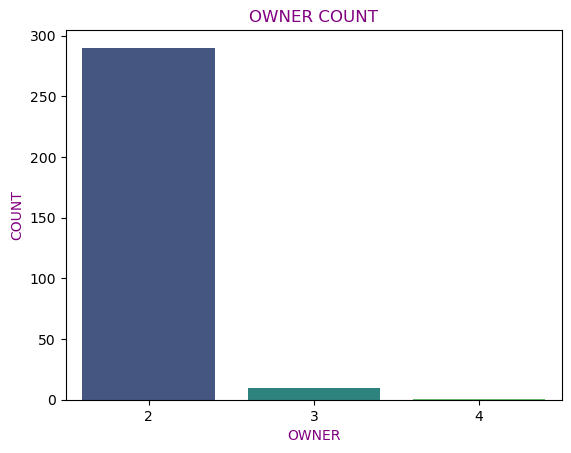

In [39]:
sns.countplot(data=df2,x="Owner",palette="viridis")
plt.xticks(rotation=0)
plt.xlabel("OWNER",fontsize=10,color="purple")
plt.ylabel("COUNT",fontsize=10,color="purple")
plt.title("OWNER COUNT",color="purple")
plt.show()

In [40]:
                                                         #Seller_Type VS Price¶


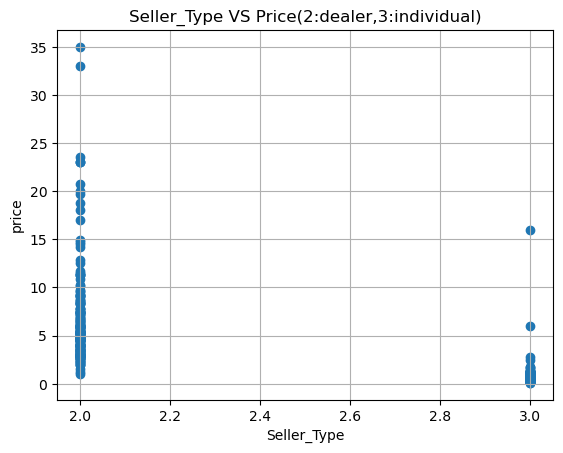

In [41]:
plt.scatter(df2["Seller_Type"], df2["Selling_Price"])
plt.title("Seller_Type VS Price(2:dealer,3:individual)")
plt.xlabel("Seller_Type")
plt.ylabel("price")
plt.grid()

In [42]:
                                                       #Transmission VS Price

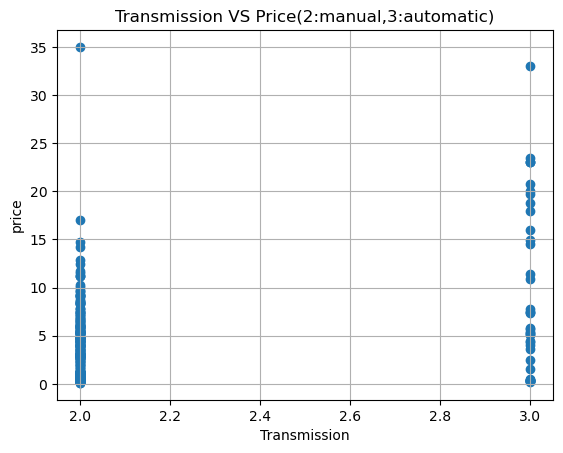

In [43]:
plt.scatter(df2["Transmission"], df2["Selling_Price"])
plt.title("Transmission VS Price(2:manual,3:automatic)")
plt.xlabel("Transmission")
plt.ylabel("price")
plt.grid()

In [44]:
                                                             #Type of columns:
                                                               #categorical:

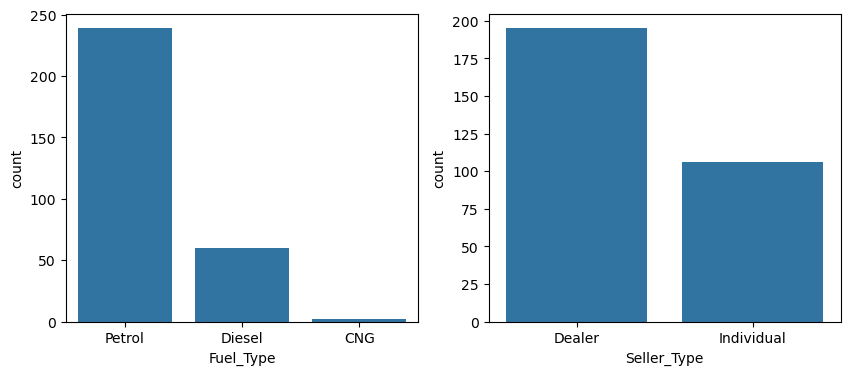

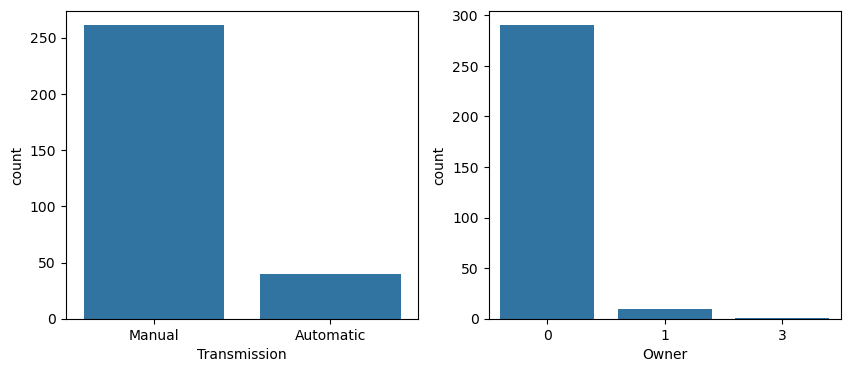

In [45]:
categorical=['Fuel_Type','Seller_Type','Transmission','Owner']
i=0
while i<4:
    fig=plt.figure(figsize=[10,4])
    plt.subplot(1,2,1)
    sns.countplot(x=categorical[i],data=data)
    i+=1
    plt.subplot(1,2,2)
    sns.countplot(x=categorical[i],data=data)
    i+=1
    plt.show()
    

In [46]:
                                                            #Numerical:

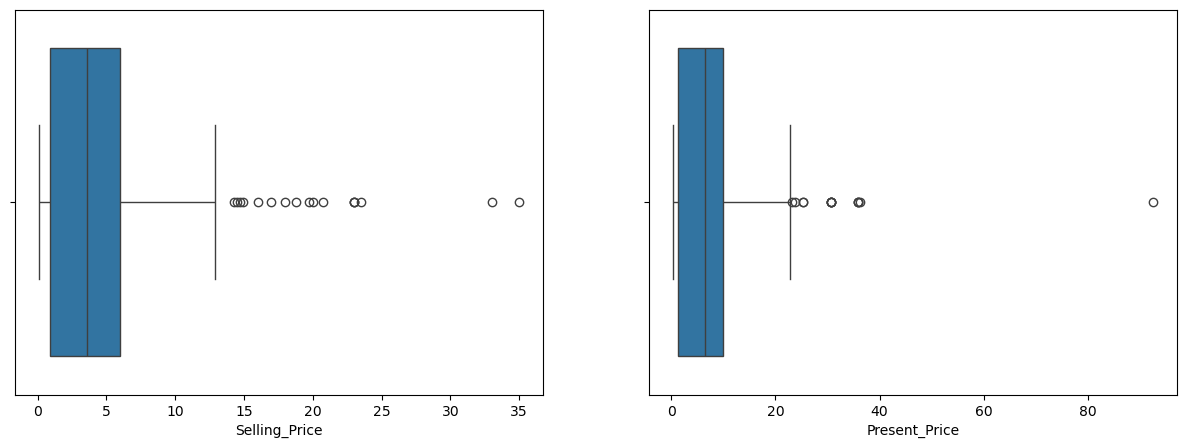

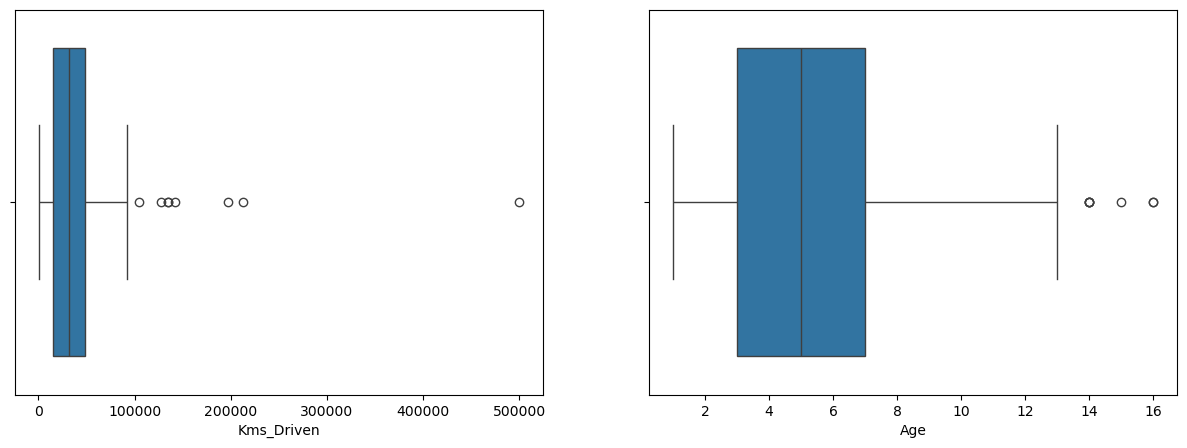

In [47]:
Numerical=['Selling_Price','Present_Price','Kms_Driven','Age']
i=0
while i<4:
    fig=plt.figure(figsize=[15,5])
    plt.subplot(1,2,1)
    sns.boxplot(x=Numerical[i],data=df2)
    i+=1
    plt.subplot(1,2,2)
    sns.boxplot(x=Numerical[i],data=df2)
    i+=1
    plt.show()
    

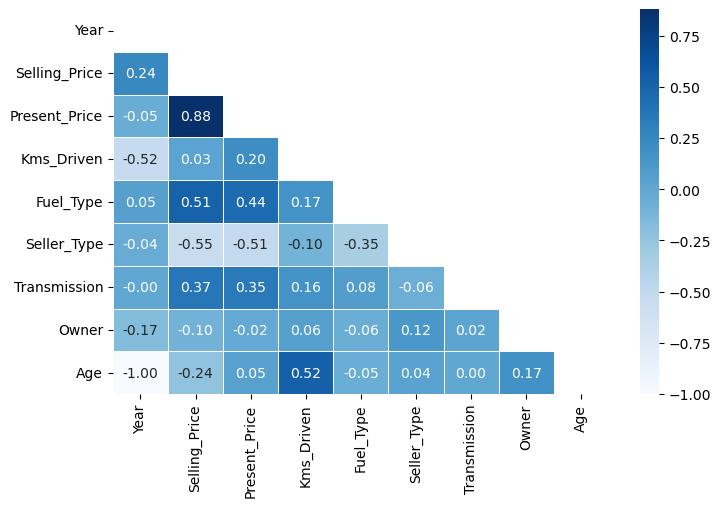

In [48]:
corr = df2.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', linewidths=0.5, linecolor='white', mask=np.triu(corr), cmap='Blues')
plt.show()

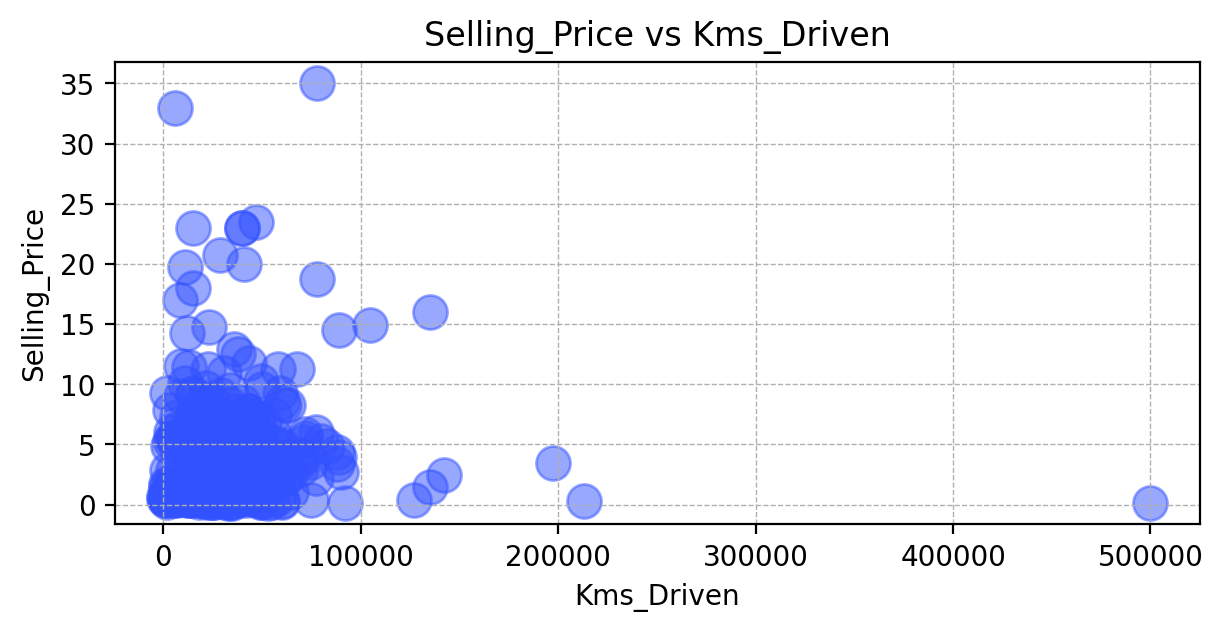

In [49]:
plt.figure(figsize=(7,3),dpi=200)      # Set the figure size
plt.scatter(df2['Kms_Driven'],df2['Selling_Price'],s=150 ,alpha=0.5 , color='#3352ff',marker='o')    # blue color scheme
plt.xlabel('Kms_Driven')        #X-axis
plt.ylabel('Selling_Price')    #y-axis
plt.title('Selling_Price vs Kms_Driven')   
plt.grid(True,linestyle='--',linewidth=0.5)    # Add grid with the same layout as the plot

plt.show()

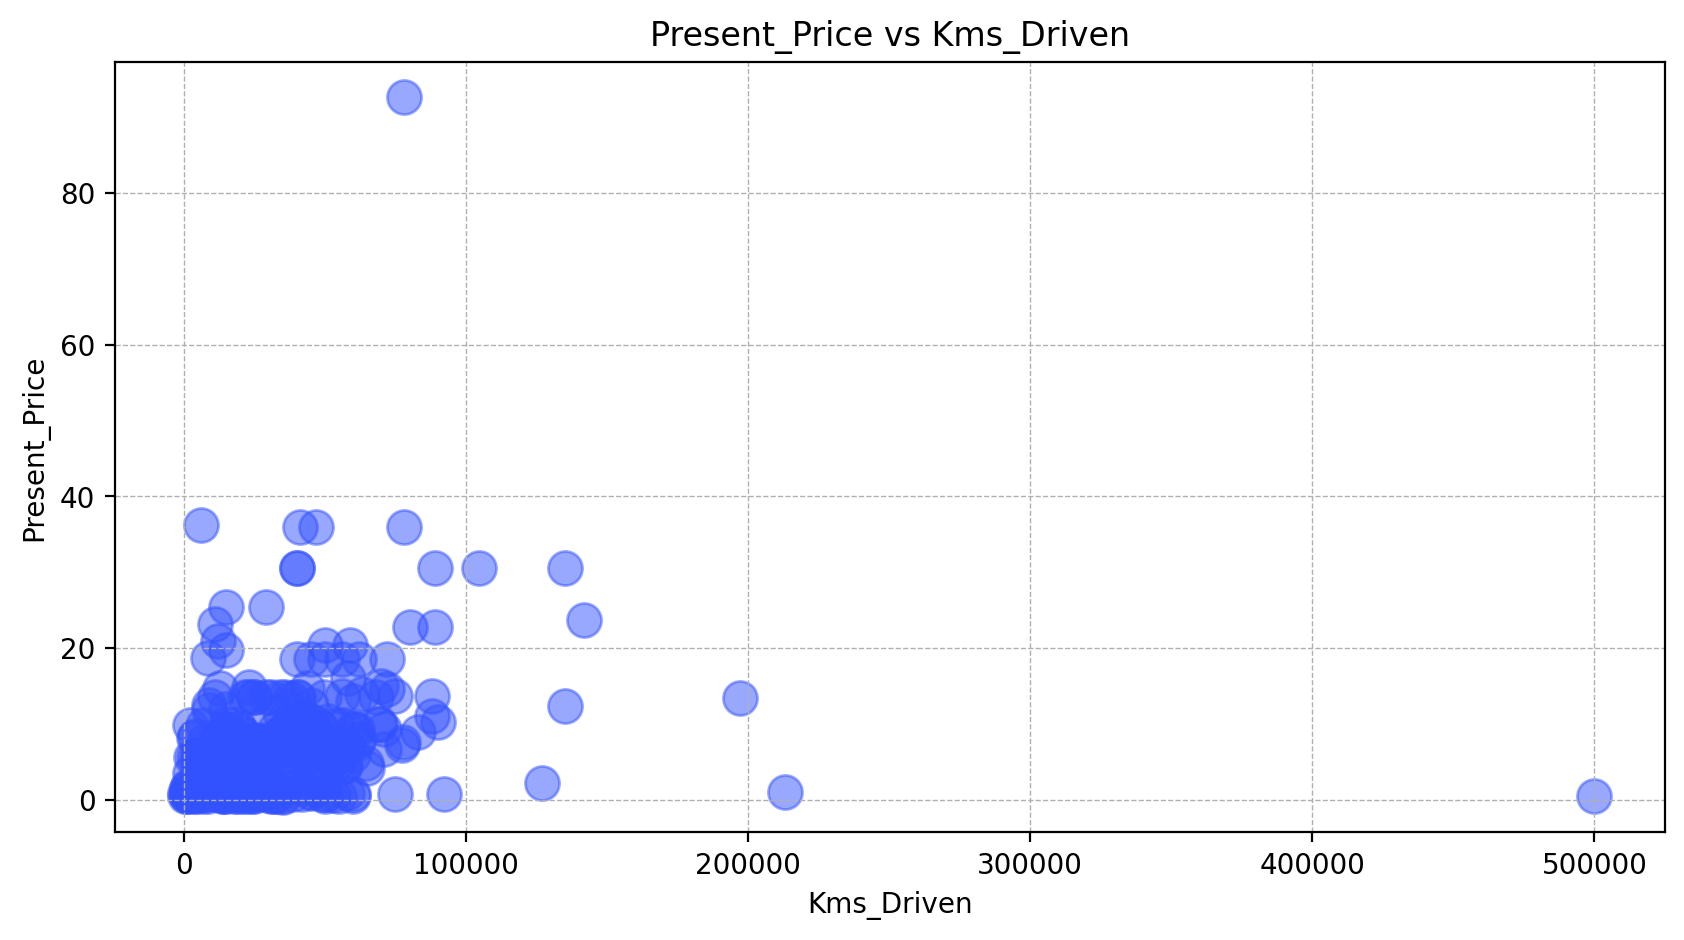

In [50]:
plt.figure(figsize=(10,5),dpi=200)      # Set the figure size
plt.scatter(df2['Kms_Driven'],df2['Present_Price'],s=150 ,alpha=0.5 , color='#3352ff',marker='o')    # blue color scheme
plt.xlabel('Kms_Driven')        #X-axis
plt.ylabel('Present_Price')    #y-axis
plt.title('Present_Price vs Kms_Driven')   
plt.grid(True,linestyle='--',linewidth=0.5)    # Add grid with the same layout as the plot

plt.show()

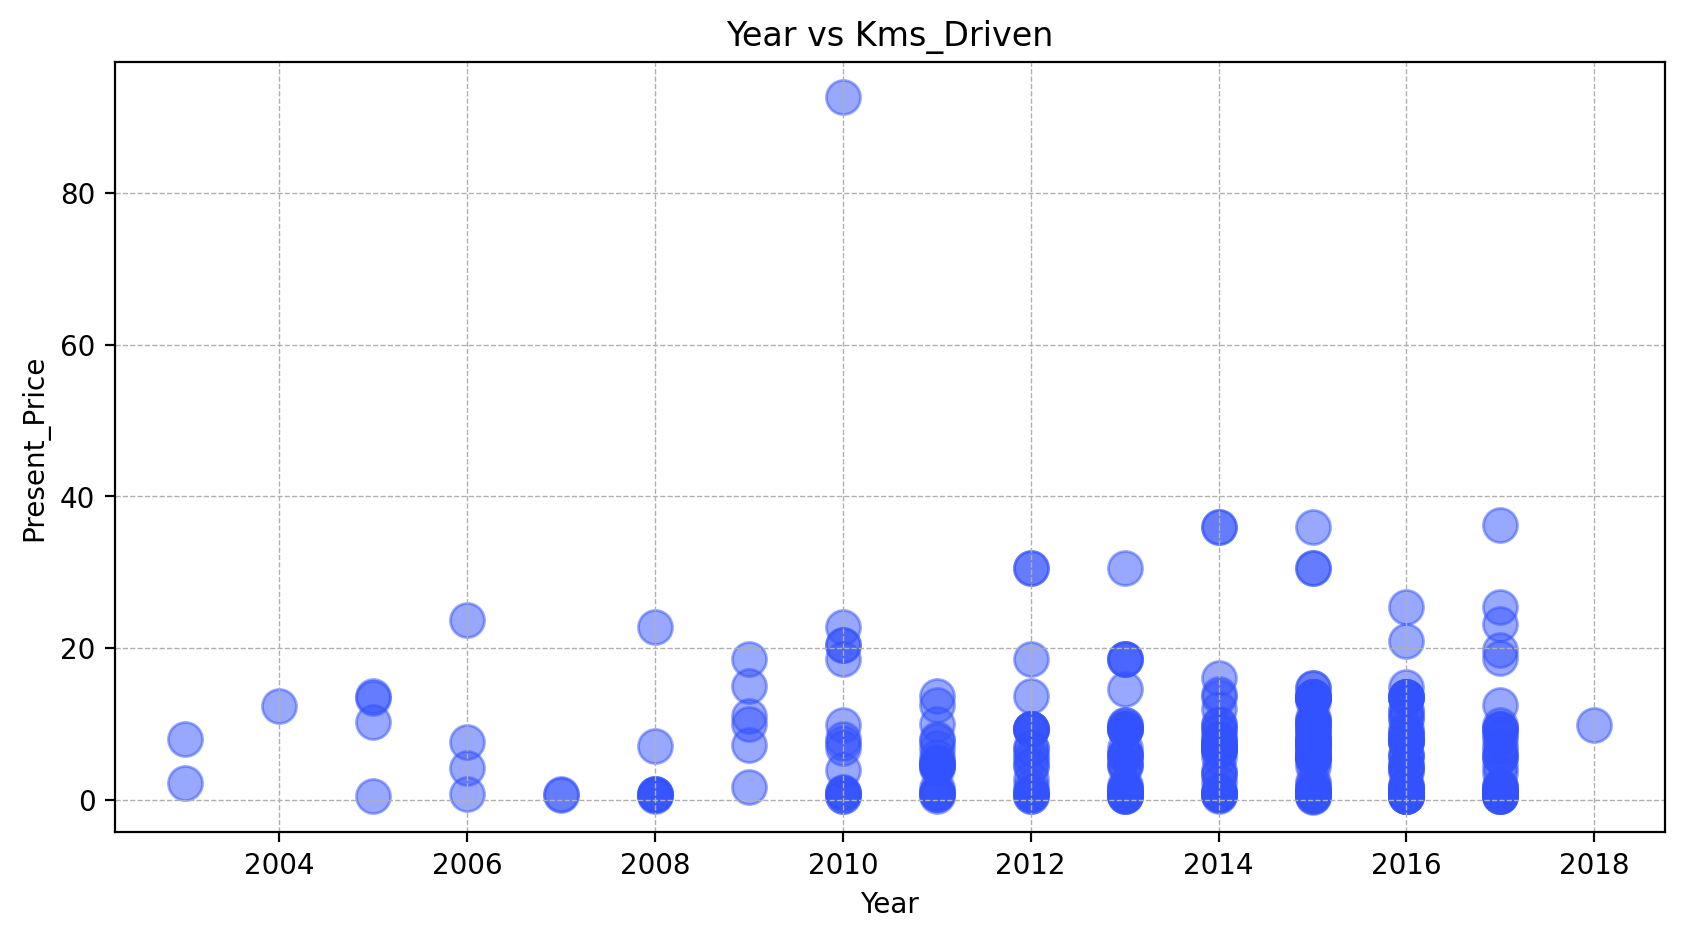

In [51]:
plt.figure(figsize=(10,5),dpi=200)      # Set the figure size
plt.scatter(df2['Year'],df2['Present_Price'],s=150 ,alpha=0.5 , color='#3352ff',marker='o')    # blue color scheme
plt.xlabel('Year')        #X-axis
plt.ylabel('Present_Price')    #y-axis
plt.title('Year vs Kms_Driven')   
plt.grid(True,linestyle='--',linewidth=0.5)    # Add grid with the same layout as the plot

plt.show()

In [52]:
                                                                      #creat model

In [53]:
df2

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,2,2,2,2,5
1,2013,4.75,9.54,43000,3,2,2,2,6
2,2017,7.25,9.85,6900,2,2,2,2,2
3,2011,2.85,4.15,5200,2,2,2,2,8
4,2014,4.60,6.87,42450,3,2,2,2,5
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,3,2,2,2,3
297,2015,4.00,5.90,60000,2,2,2,2,4
298,2009,3.35,11.00,87934,2,2,2,2,10
299,2017,11.50,12.50,9000,3,2,2,2,2


In [54]:
X = pd.DataFrame(df2,columns = ["Year","Present_Price","Kms_Driven","Fuel_Type","Seller_Type","Transmission","Owner","Age"])
y = df2['Selling_Price'].values.reshape(-1,1)

In [55]:
 x_train ,x_test, y_train, y_test = train_test_split(X, y,test_size = 0.2,random_state = 0)

In [56]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [57]:
y_pred = regressor.predict(x_test)

In [58]:
print('Mean_absolute_error: ', metrics.mean_absolute_error(y_test,y_pred))
print('Mean squared error: ', metrics.mean_squared_error(y_test,y_pred))
print('Root Mean squared error: ',np.sqrt( metrics.mean_squared_error(y_test,y_pred)))
print('R2 score : ',metrics.r2_score(y_test,y_pred))

Mean_absolute_error:  0.9878455147795975
Mean squared error:  2.1697659587234415
Root Mean squared error:  1.4730125453381044
R2 score :  0.9141615455495808


In [59]:
#intercept
print(regressor.intercept_)
#slop
print(regressor.coef_)

[-398.51174514]
[[ 1.98282656e-01  4.35221263e-01 -5.58942075e-06  1.45811985e+00
  -1.14871763e+00  1.41141956e+00 -8.56847731e-01 -1.98282656e-01]]


In [60]:
                                                                      # improve model 

In [61]:
kfold = KFold(10)
reg_score = cross_val_score(regressor, X,y, cv=kfold)
print(reg_score)
print(np.mean(reg_score))

[ 6.59725854e-01  8.79877160e-01  7.26575045e-01  8.63797443e-01
 -4.36423046e+01 -1.06849476e+03 -4.23158290e-01  7.84993068e-01
  8.30627713e-01  8.75076429e-01]
-110.69395549175962


In [62]:
len(df2)/10

30.1

In [63]:
df4 = df2[df2.index<120]
df5 = df2[df2.index>210]
df6 = pd.concat([df4, df5])
df6.reset_index(drop = True, inplace = True)

In [64]:
df6

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,2,2,2,2,5
1,2013,4.75,9.54,43000,3,2,2,2,6
2,2017,7.25,9.85,6900,2,2,2,2,2
3,2011,2.85,4.15,5200,2,2,2,2,8
4,2014,4.60,6.87,42450,3,2,2,2,5
...,...,...,...,...,...,...,...,...,...
205,2016,9.50,11.60,33988,3,2,2,2,3
206,2015,4.00,5.90,60000,2,2,2,2,4
207,2009,3.35,11.00,87934,2,2,2,2,10
208,2017,11.50,12.50,9000,3,2,2,2,2


In [65]:
X2 = pd.DataFrame(df6,columns = ["Year","Present_Price","Kms_Driven","Fuel_Type","Seller_Type","Transmission","Owner","Age"])
y2 = df6['Selling_Price'].values.reshape(-1,1)

In [66]:
 x_train2 ,x_test2, y_train2, y_test2 = train_test_split(X2, y2,test_size = 0.2,random_state = 0)

In [67]:
model2 = LinearRegression()
model2.fit(x_train2,y_train2)

LinearRegression()

In [68]:
y_pred2 = regressor.predict(x_test2)

In [69]:
print('Mean_absolute_error: ', metrics.mean_absolute_error(y_test2,y_pred2))
print('Mean squared error: ', metrics.mean_squared_error(y_test2,y_pred2))
print('Root Mean squared error: ',np.sqrt( metrics.mean_squared_error(y_test2,y_pred2)))
print('R2 score : ',metrics.r2_score(y_test2,y_pred2))

Mean_absolute_error:  1.5224183672104397
Mean squared error:  5.152350012347895
Root Mean squared error:  2.2698788541126804
R2 score :  0.870670961314777


In [70]:
kfold = KFold(5)
reg_score = cross_val_score(regressor, X2,y2, cv=kfold)
print(reg_score)
print(np.mean(reg_score))

[-0.21969128  0.83230922  0.63611423  0.73633213  0.90865343]
0.578743545713899


In [71]:
kfold = KFold(10)
reg_score = cross_val_score(regressor, X2,y2, cv=kfold)
print(reg_score)
print(np.mean(reg_score))

[ 0.48423924 -1.07218307  0.91502843  0.79590003  0.69969487  0.81491041
  0.74156213  0.79018155  0.9137762   0.90801714]
0.5991126933371491


In [72]:

from sklearn.metrics import r2_score

def best_r2_score(X: pd.DataFrame, y: pd.DataFrame, test_size: float, k_folds: int) -> dict:
       # Divide the data into two parts: training and testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0)

    #  KFold
    kf = KFold(n_splits=k_folds)
    best_r2_scores = {}

   
    for column in y.columns:
        r2_scores = []

        for train_index, val_index in kf.split(X_train):
            X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
            y_train_fold, y_val_fold = y_train.iloc[train_index][column], y_train.iloc[val_index][column]

            # train model
            model = LinearRegression()
            model.fit(X_train_fold, y_train_fold)

            # Prediction and calculation of R² score
            y_val_pred = model.predict(X_val_fold)
            r2 = r2_score(y_val_fold, y_val_pred)
            r2_scores.append(r2)

         # Save the best R² score for each column
        best_r2_scores = max(r2_scores)

    return best_r2_scores



In [73]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.1, 5)
print(result)                                                    #r2 score for test size = 0.1 and k fold = 5

0.92009019606459


In [74]:
best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.15, 5)                    #r2 score for test size = 0.15 and k fold = 5

0.9172634313463078

In [75]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.2, 5)
print(result)                                                      #r2 score for test size = 0.2 and k fold = 5

0.9289480448308268


In [76]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.25, 5)
print(result)                                                     #r2 score for test size = 0.0.25 and k fold = 5

0.8957395791047378


In [77]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.3, 5)
print(result)                                                         #r2 score for test size = 0.3 and k fold = 5

0.9250814261136007


In [78]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.1, 10)
print(result)                                                         #r2 score for test size = 0.1 and k fold = 10

0.9660942844554625


In [79]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.15, 10)
print(result)                                                         #r2 score for test size = 0.15 and k fold = 10

0.9491020459514108


In [80]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.2, 10)
print(result)                                                         #r2 score for test size = 0.2 and k fold = 10

0.9673956002796867


In [81]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.25, 10)
print(result)                                                        #r2 score for test size = 0.25 and k fold = 10

0.9232220886984039


In [82]:
result = best_r2_score(pd.DataFrame(df6.drop(columns = ['Selling_Price']))
, pd.DataFrame(df6['Selling_Price']), 0.3, 10)
print(result)                                                        #r2 score for test size = 0.3 and k fold = 10

0.9320364874519388


In [83]:
                                                            # improve model 

In [84]:
                                                            #X^2 dimension

In [85]:
for column in X:
    
    new_col_name = column +str(2)
    new_column_val = X[column]**2
    X.insert(0,new_col_name,new_column_val)

In [86]:
X

,Age2,Owner2,Transmission2,Seller_Type2,Fuel_Type2,Kms_Driven2,Present_Price2,Year2,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,25,4,4,4,4,729000000,31.2481,4056196,2014,5.59,27000,2,2,2,2,5
1,36,4,4,4,9,1849000000,91.0116,4052169,2013,9.54,43000,3,2,2,2,6
2,4,4,4,4,4,47610000,97.0225,4068289,2017,9.85,6900,2,2,2,2,2
3,64,4,4,4,4,27040000,17.2225,4044121,2011,4.15,5200,2,2,2,2,8
4,25,4,4,4,9,1802002500,47.1969,4056196,2014,6.87,42450,3,2,2,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,9,4,4,4,9,1155184144,134.5600,4064256,2016,11.60,33988,3,2,2,2,3
297,16,4,4,4,4,3600000000,34.8100,4060225,2015,5.90,60000,2,2,2,2,4
298,100,4,4,4,4,7732388356,121.0000,4036081,2009,11.00,87934,2,2,2,2,10
299,4,4,4,4,9,81000000,156.2500,4068289,2017,12.50,9000,3,2,2,2,2


In [87]:
 x_train ,x_test, y_train, y_test = train_test_split(X, y,test_size = 0.2,random_state = 0)

In [88]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [89]:
y_pred = regressor.predict(x_test)

In [90]:
print('Mean_absolute_error: ', metrics.mean_absolute_error(y_test,y_pred))
print('Mean squared error: ', metrics.mean_squared_error(y_test,y_pred))
print('Root Mean squared error: ',np.sqrt( metrics.mean_squared_error(y_test,y_pred)))
print('R2 score : ',metrics.r2_score(y_test,y_pred))

Mean_absolute_error:  1.0823497842486003
Mean squared error:  1.8530328191143652
Root Mean squared error:  1.3612614808016736
R2 score :  0.9266918754074921


In [91]:
                                                       # dot product

In [92]:
pres_Kms = X["Present_Price"]*X["Kms_Driven"]
pres_Kms2 = X["Present_Price"]*X["Kms_Driven2"]
pres_fuel = X["Present_Price"]*X["Fuel_Type"]
pres_fuel2 = X["Present_Price"]*X["Fuel_Type2"]
pres2_Kms = X["Present_Price2"]*X["Kms_Driven"]
pres2_Kms2 = X["Present_Price2"]*X["Kms_Driven2"]
pres2_fuel = X["Present_Price2"]*X["Fuel_Type"]
pres2_fuel2 = X["Present_Price2"]*X["Fuel_Type2"]


In [93]:
X.insert(0,"pres_Kms",pres_Kms)
X.insert(0,"pres_Kms2",pres_Kms2)
X.insert(0,"pres_fuel",pres_fuel)
X.insert(0,"pres_fuel2",pres_fuel2)
X.insert(0,"pres2_Kms",pres2_Kms)
X.insert(0,"pres2_Kms2",pres2_Kms2)
X.insert(0,"pres2_fuel",pres2_fuel)
X.insert(0,"pres2_fuel2",pres2_fuel2)
X

,pres2_fuel2,pres2_fuel,pres2_Kms2,pres2_Kms,pres_fuel2,pres_fuel,pres_Kms2,pres_Kms,Age2,Owner2,...,Present_Price2,Year2,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,124.9924,62.4962,2.277986e+10,8.436987e+05,22.36,11.18,4.075110e+09,150930.0,25,4,...,31.2481,4056196,2014,5.59,27000,2,2,2,2,5
1,819.1044,273.0348,1.682804e+11,3.913499e+06,85.86,28.62,1.763946e+10,410220.0,36,4,...,91.0116,4052169,2013,9.54,43000,3,2,2,2,6
2,388.0900,194.0450,4.619241e+09,6.694552e+05,39.40,19.70,4.689585e+08,67965.0,4,4,...,97.0225,4068289,2017,9.85,6900,2,2,2,2,2
3,68.8900,34.4450,4.656964e+08,8.955700e+04,16.60,8.30,1.122160e+08,21580.0,64,4,...,17.2225,4044121,2011,4.15,5200,2,2,2,2,8
4,424.7721,141.5907,8.504893e+10,2.003508e+06,61.83,20.61,1.237976e+10,291631.5,25,4,...,47.1969,4056196,2014,6.87,42450,3,2,2,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,1211.0400,403.6800,1.554416e+11,4.573425e+06,104.40,34.80,1.340014e+10,394260.8,9,4,...,134.5600,4064256,2016,11.60,33988,3,2,2,2,3
297,139.2400,69.6200,1.253160e+11,2.088600e+06,23.60,11.80,2.124000e+10,354000.0,16,4,...,34.8100,4060225,2015,5.90,60000,2,2,2,2,4
298,484.0000,242.0000,9.356190e+11,1.064001e+07,44.00,22.00,8.505627e+10,967274.0,100,4,...,121.0000,4036081,2009,11.00,87934,2,2,2,2,10
299,1406.2500,468.7500,1.265625e+10,1.406250e+06,112.50,37.50,1.012500e+09,112500.0,4,4,...,156.2500,4068289,2017,12.50,9000,3,2,2,2,2


In [94]:
 x_train ,x_test, y_train, y_test = train_test_split(X, y,test_size = 0.2,random_state = 0)

In [95]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [96]:
y_pred = regressor.predict(x_test)

In [97]:
print('Mean_absolute_error: ', metrics.mean_absolute_error(y_test,y_pred))
print('Mean squared error: ', metrics.mean_squared_error(y_test,y_pred))
print('Root Mean squared error: ',np.sqrt( metrics.mean_squared_error(y_test,y_pred)))
print('R2 score : ',metrics.r2_score(y_test,y_pred))

Mean_absolute_error:  0.7132278600290444
Mean squared error:  1.1387928171751904
Root Mean squared error:  1.06714236031337
R2 score :  0.9549480371500212


In [98]:
kfold = KFold(5)
reg_score = cross_val_score(regressor, X2,y2, cv=kfold)
print(reg_score)
print(np.mean(reg_score))

[-0.21969128  0.83230922  0.63611423  0.73633213  0.90865343]
0.578743545713899


In [99]:
X.shape

(301, 24)

In [100]:
301/5

60.2

In [101]:
X_new = X[X.index>61]
X_new.reset_index(drop = True, inplace = True)
X_new

,pres2_fuel2,pres2_fuel,pres2_Kms2,pres2_Kms,pres_fuel2,pres_fuel,pres_Kms2,pres_Kms,Age2,Owner2,...,Present_Price2,Year2,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,11638.0944,3879.3648,7.867352e+12,1.008635e+08,323.64,107.88,2.187806e+11,2804880.0,25,4,...,1293.1216,4056196,2014,35.96,78000,3,2,3,2,5
1,11638.0944,3879.3648,2.856506e+12,6.077672e+07,323.64,107.88,7.943564e+10,1690120.0,16,4,...,1293.1216,4060225,2015,35.96,47000,3,2,3,2,4
2,11813.5161,3937.8387,4.725406e+10,7.875677e+06,326.07,108.69,1.304280e+09,217380.0,4,4,...,1312.6129,4068289,2017,36.23,6000,3,2,3,2,2
3,434.7225,144.9075,9.781256e+10,2.173612e+06,62.55,20.85,1.407375e+10,312750.0,25,4,...,48.3025,4056196,2014,6.95,45000,3,2,2,2,5
4,2143.6900,1071.8450,6.484662e+10,5.895147e+06,92.60,46.30,2.801150e+09,254650.0,4,4,...,535.9225,4068289,2017,23.15,11000,2,2,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,1211.0400,403.6800,1.554416e+11,4.573425e+06,104.40,34.80,1.340014e+10,394260.8,9,4,...,134.5600,4064256,2016,11.60,33988,3,2,2,2,3
235,139.2400,69.6200,1.253160e+11,2.088600e+06,23.60,11.80,2.124000e+10,354000.0,16,4,...,34.8100,4060225,2015,5.90,60000,2,2,2,2,4
236,484.0000,242.0000,9.356190e+11,1.064001e+07,44.00,22.00,8.505627e+10,967274.0,100,4,...,121.0000,4036081,2009,11.00,87934,2,2,2,2,10
237,1406.2500,468.7500,1.265625e+10,1.406250e+06,112.50,37.50,1.012500e+09,112500.0,4,4,...,156.2500,4068289,2017,12.50,9000,3,2,2,2,2


In [102]:
y = df2["Selling_Price"]
y_new =y[y.index>61]
y_new.reset_index(drop = True , inplace = True)
y_new.shape

(239,)

In [103]:
 x_train ,x_test, y_train, y_test = train_test_split(X_new, y_new,test_size = 0.2,random_state = 0)

In [104]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [105]:
y_pred = regressor.predict(x_test)

In [106]:
print('Mean_absolute_error: ', metrics.mean_absolute_error(y_test,y_pred))
print('Mean squared error: ', metrics.mean_squared_error(y_test,y_pred))
print('Root Mean squared error: ',np.sqrt( metrics.mean_squared_error(y_test,y_pred)))
print('R2 score : ',metrics.r2_score(y_test,y_pred))

Mean_absolute_error:  0.8029262354906125
Mean squared error:  1.2389804997050786
Root Mean squared error:  1.113095009289449
R2 score :  0.9302299769439271


In [107]:
scaler = MinMaxScaler(feature_range=(0, 1))
print(X_new[0:5])
X_new.insert(0,"target",y_new)
DataFrame = X_new
DataFrame
# fit data to normalize
Normalized = scaler.fit_transform(DataFrame)
print(Normalized[0:5])
# Convert normalized data to a new DataFrame
#df3 = pd.DataFrame(Normalized, columns=df2.columns)

   pres2_fuel2  pres2_fuel    pres2_Kms2    pres2_Kms  pres_fuel2  pres_fuel  \
0   11638.0944   3879.3648  7.867352e+12  100863484.8      323.64     107.88   
1   11638.0944   3879.3648  2.856506e+12   60776715.2      323.64     107.88   
2   11813.5161   3937.8387  4.725406e+10    7875677.4      326.07     108.69   
3     434.7225    144.9075  9.781256e+10    2173612.5       62.55      20.85   
4    2143.6900   1071.8450  6.484662e+10    5895147.5       92.60      46.30   

      pres_Kms2   pres_Kms  Age2  Owner2  ...  Present_Price2    Year2  Year  \
0  2.187806e+11  2804880.0    25       4  ...       1293.1216  4056196  2014   
1  7.943564e+10  1690120.0    16       4  ...       1293.1216  4060225  2015   
2  1.304280e+09   217380.0     4       4  ...       1312.6129  4068289  2017   
3  1.407375e+10   312750.0    25       4  ...         48.3025  4056196  2014   
4  2.801150e+09   254650.0     4       4  ...        535.9225  4068289  2017   

   Present_Price  Kms_Driven  Fuel_Typ

In [108]:
X_norm = DataFrame.drop(["target"],axis=1)
y_norm = DataFrame["target"].values.reshape(-1,1)

In [109]:
 x_train ,x_test, y_train, y_test = train_test_split(X_norm, y_norm,test_size = 0.2,random_state = 0)

In [110]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [111]:
y_pred = regressor.predict(x_test)

In [112]:
print('Mean_absolute_error: ', metrics.mean_absolute_error(y_test,y_pred))
print('Mean squared error: ', metrics.mean_squared_error(y_test,y_pred))
print('Root Mean squared error: ',np.sqrt( metrics.mean_squared_error(y_test,y_pred)))
print('R2 score : ',metrics.r2_score(y_test,y_pred))

Mean_absolute_error:  0.8029262354906125
Mean squared error:  1.2389804997050786
Root Mean squared error:  1.113095009289449
R2 score :  0.9302299769439271


In [113]:
                                                            # predict given data
# input 
# present price  = 11.23
# Kms_Driven = 42000
# fuel_type = petrol
# seller type = dealler
# Transmission = manual
# owner = 1
# age = 10
# price = ?

In [114]:
DataFrame.columns

Index(['target', 'pres2_fuel2', 'pres2_fuel', 'pres2_Kms2', 'pres2_Kms',
       'pres_fuel2', 'pres_fuel', 'pres_Kms2', 'pres_Kms', 'Age2', 'Owner2',
       'Transmission2', 'Seller_Type2', 'Fuel_Type2', 'Kms_Driven2',
       'Present_Price2', 'Year2', 'Year', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Age'],
      dtype='object')

In [115]:
present_price  = 11.23
Kms_Driven = 42000
fuel_type = 2
seller_type = 2
Transmission = 2
owner = 1
age = 10

model_input = pd.DataFrame({'target': 10,
                           'pres2_fuel2'   :[((present_price**2) * (fuel_type**2))],
                           'pres2_fuel'    :[((present_price**2) * (fuel_type))],
                           'pres2_Kms2'    :[((present_price**2) * (Kms_Driven**2))],
                           'pres2_Kms'     :[((present_price**2) * (Kms_Driven))],
                           'pres_fuel2'    :[((present_price) * (fuel_type)**2)],
                           'pres_fuel'     :[((present_price) * (fuel_type))],
                           'pres_Kms2'     :[((present_price) * (Kms_Driven)**2)],
                           'pres_Kms'      :[((present_price) * (Kms_Driven))],
                           'Age2'          :[(age) **2],
                           'Owner2'        :[(owner) **2],
                           'Transmission2' :[(Transmission) **2],
                           'Seller_Type2'  :[(seller_type)**2],
                           'Fuel_Type2'    :[(fuel_type**2)],
                           'Kms_Driven2'   :[((Kms_Driven)**2)],
                           'Present_Price2':[(present_price**2)],
                           'Year2'         :[(2019-10)**2],
                           'Year'          : 2009,
                           'Present_Price' :[(present_price)],
                           'Kms_Driven'    :[(Kms_Driven)],
                           'Fuel_Type'     :[(fuel_type)],
                           'Seller_Type'   :[(seller_type)],
                           'Transmission'  :[(Transmission)],
                           'Owner'         :[(owner)],
                           'Age'           :[(age)]
                           })

In [116]:
model_input

,target,pres2_fuel2,pres2_fuel,pres2_Kms2,pres2_Kms,pres_fuel2,pres_fuel,pres_Kms2,pres_Kms,Age2,...,Present_Price2,Year2,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,10,504.4516,252.2258,2.224632e+11,5296741.8,44.92,22.46,1.980972e+10,471660.0,100,...,126.1129,4036081,2009,11.23,42000,2,2,2,1,10


In [117]:
Finall =result = pd.concat([DataFrame, model_input], ignore_index=True)

In [118]:
Finall

,target,pres2_fuel2,pres2_fuel,pres2_Kms2,pres2_Kms,pres_fuel2,pres_fuel,pres_Kms2,pres_Kms,Age2,...,Present_Price2,Year2,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,18.75,11638.0944,3879.3648,7.867352e+12,1.008635e+08,323.64,107.88,2.187806e+11,2804880.0,25,...,1293.1216,4056196,2014,35.96,78000,3,2,3,2,5
1,23.50,11638.0944,3879.3648,2.856506e+12,6.077672e+07,323.64,107.88,7.943564e+10,1690120.0,16,...,1293.1216,4060225,2015,35.96,47000,3,2,3,2,4
2,33.00,11813.5161,3937.8387,4.725406e+10,7.875677e+06,326.07,108.69,1.304280e+09,217380.0,4,...,1312.6129,4068289,2017,36.23,6000,3,2,3,2,2
3,4.75,434.7225,144.9075,9.781256e+10,2.173612e+06,62.55,20.85,1.407375e+10,312750.0,25,...,48.3025,4056196,2014,6.95,45000,3,2,2,2,5
4,19.75,2143.6900,1071.8450,6.484662e+10,5.895147e+06,92.60,46.30,2.801150e+09,254650.0,4,...,535.9225,4068289,2017,23.15,11000,2,2,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,4.00,139.2400,69.6200,1.253160e+11,2.088600e+06,23.60,11.80,2.124000e+10,354000.0,16,...,34.8100,4060225,2015,5.90,60000,2,2,2,2,4
236,3.35,484.0000,242.0000,9.356190e+11,1.064001e+07,44.00,22.00,8.505627e+10,967274.0,100,...,121.0000,4036081,2009,11.00,87934,2,2,2,2,10
237,11.50,1406.2500,468.7500,1.265625e+10,1.406250e+06,112.50,37.50,1.012500e+09,112500.0,4,...,156.2500,4068289,2017,12.50,9000,3,2,2,2,2
238,5.30,139.2400,69.6200,1.039263e+09,1.902018e+05,23.60,11.80,1.761462e+08,32237.6,9,...,34.8100,4064256,2016,5.90,5464,2,2,2,2,3


In [119]:
X = Finall.drop(['target'],axis=1)[:239]
y = Finall[['target']][:239]
X_Finall =Finall.drop(['target'],axis =1)[239:]

In [120]:
regressor.fit(X,y)

LinearRegression()

In [121]:
y_pred = regressor.predict(X_Finall)

In [122]:
y_pred

array([[4.900521]])

In [123]:
   # finall answer = 4.900521 ,   price = 4.900521